# PyCatan Tutorial 1

The tutorial overview is found at this [link](https://github.com/robhendrik/PyCatan/blob/main/docs/PyCatan_tutorial_overview.ipynb). Full source code and documentation can be found in the [Github repo for PyCatan](https://github.com/robhendrik/PyCatan/)

In [1]:
from pathlib import Path
import sys
import os
from IPython import get_ipython

# Ensure local `src/` is on sys.path so we can import the package from the notebook
nb_dir = Path().resolve()
# Add repo-relative src folders (not permanent)
sys.path.insert(0, str(nb_dir / ".." / "src"))
sys.path.insert(0, str(nb_dir / "src"))

try:
    import Py_Catan_AI as pc
except Exception as exc:
    raise ImportError(
        "Could not import `Py_Catan_AI`. Make sure the project's `src/` directory is present and dependencies are installed.\n"
        "If you are running the notebook from a different working directory, try setting the notebook's working directory to the repository root."
    ) from exc

# Convenience: access IPython when available
ip = get_ipython()

In [2]:
# Set working directory to repo root
os.chdir(pc.get_repo_root(target_name="PyCatan"))

# Determine if running in Jupyter Notebook or as a script and load args accordingly
if get_ipython():
    print("Running in Jupyter Notebook")
    args = pc.Args()
else:
    print("Running as Script")
    args = pc.parse_args()

Running in Jupyter Notebook


# PyCatan game tutorial: The Game
This is the PyCatan "game" tutorial, the first in a series of six. This tutorial introduces the game environment used to play a simplified version of the Catan game. We will use this game environment to train AI players to learn from their own play.

The rules of the game are simplified. We use a regular Catan board, but there are no harbours, robber, or development cards. Players can build streets, villages, and towns, and they can trade with each other. If the dice roll a "seven", players with more than seven cards in hand must hand in a random selection of half their cards (in the real game the player can select; here it is at random). Players score victory points by building villages (1 VP), towns (2 VP), or by owning the longest street (2 VP).

In this tutorial we show how players play the game and how to visualize it (a snapshot taken at any moment), or how to create a video from the game. To create a video you need FFmpeg installed. See: https://matplotlib.org/stable/users/explain/animations/animations.html

We can give players individual personalities. When we do this the players can speak, in character, about the game. This "verbalization" is realised through the OpenAI API. If you want to replicate this you need to provide a key to access OpenAI. See: https://help.openai.com/en/articles/5112595-best-practices-for-api-key-safety

### The tutorials

- Running a game, including generating a game visualization/video with players speaking in character
- Running a tournament
- Data generation for bootstrapping a model
- Model training for bootstrapping reinforcement learning
- Reinforcement learning to train a model
- Running an evaluation tournament to check the performance of a model

### Directory structure

<pre>
PyCatan/
├── docs/ # contains tutorials in Jupyter Notebook format
├── scripts/ # contains scripts to be run command 
├── bootstrap/ # contains data and models used for bootstrapping RL learning
└── src/
    └── Py_Catan_AI/
        ├── models/ # contains the 'default' models used when creating a new instance
        ├── data/ # contains some default data
        └── visuals/ # contains some images used for visualization
</pre>

## Game layout

The game uses two data structures. We have a state vector describing the board state. This vector indicates which nodes have a village or town and who owns them. It also indicates which edges have streets and what cards players have in their hands. The state vector has length 159 and provides a full description of the game at any moment.

We also have an action-space mask that indicates the legal actions for a given player, given the board state (the action mask is derived directly from the state vector). The mask has length 241 and contains actions to build (for example, build a street on edge 0 or build a town on node 10) and actions to trade (for example, propose to trade a wood for an ore). The mask uses 1 for legal actions and 0 for illegal actions. If a player does not have the cards required to build a street, all build-street actions will have value 0; similarly, if the player does not have ore, all trade actions offering ore will have value 0. The first index of the mask indicates the "pass" action (i.e., do nothing and pass the turn to the next player). In the setup phase this action is not allowed; during regular gameplay it is allowed.

In [3]:
layout = pc.BoardLayout(tile_layout='DSWOSBWWGSGSBGWOGOB')
structure = pc.BoardStructure(board_layout=layout)

In [4]:
print("=== Board structure information: The state vector ===")
print(f"The length of the vector describing the board state is {structure.vector_space_length}")
print(f"The meaning of the vector indices can be read from the header: ")
print(",".join(structure.vector_space_header[20:25] + ["..."] + structure.vector_space_header[105:110]  ))
print("\n=== Board structure information: The action mask ===")
print(f"The length of the action space is {structure.mask_space_length}")
print(f"The meaning of the action indices can be read from the header: ")
print(",".join(structure.mask_space_header[:5] + ["..."] + structure.mask_space_header[125:130]  ))

=== Board structure information: The state vector ===
The length of the vector describing the board state is 159
The meaning of the vector indices can be read from the header: 
node_11,node_12,node_13,node_14,node_15,...,egde_42,egde_43,egde_44,egde_45,egde_46

=== Board structure information: The action mask ===
The length of the action space is 241
The meaning of the action indices can be read from the header: 
pass,street_0,street_1,street_2,street_3,...,village_52,village_53,town_0,town_1,town_2


## Players

Players receive two inputs: the state vector (describing the board) and the action mask (legal actions). They are also informed whether the game is in the setup phase or in regular gameplay. Based on this input, players must decide on the best action and provide that action to the game for execution. As noted above, one possible action is to "pass", which hands the turn to the next player.

If a player proposes a trade, we ask the other players—following the fixed order around the board—whether they want to accept it. The first player to accept receives the trade. If all players decline, the trade fails.

So, a player must do three things:

- Decide on the best action during the setup phase based on the board state. Depending on the state, the player either builds a village or a street.
- Decide on the best action during regular gameplay based on the board state. They select the best action from the set of legal actions provided.
- Reply to trade requests, either accepting or declining.

Initially we provide "value-based" players that use a heuristic formula derived from human experience. This heuristic assigns a value to a board for a given player: a board where a player controls streets is more valuable than one without, and a village on a good node is worth more than a village on a poor node. Using this heuristic, players can compete. In later tutorials we introduce players implemented as Keras models, which learn and improve from their own actions.

Random and passive players are also available. These are mainly used for debugging; in actual gameplay they tend to produce very long games with little progress.


In [5]:
player_names = ['player A', 'player B', 'player C', 'player D']
value_players = [pc.ValueBasedCatanPlayer(structure, name) for name in player_names]

# We can also select different player types, e.g., random players or passive players:
random_players = [pc.RandomCatanPlayer(structure, name) for name in player_names] # random player make random valid moves
# passive players always pass their turn, this will be a long game!
passive_players = [pc.CompletelyPassiveCatanPlayer(structure, name) for name in player_names] # passive players always pass their turn

## Game environment

Once we have the players defined, running the game is straightforward. The game is logged in `game_log`. This log can be used to evaluate the game's outcome or visualize the game.

In [6]:
game = pc.PyCatanGame(structure=structure, max_rounds = 51, victory_points_to_win=8)
game_log = game.play_catan_game(value_players)
print(game.summarize_game_results(game_log))
print(f"Ranking: {game.score_to_rankings(game_log.log.iloc[-1]['score'])}")

Game ended in 20 rounds. 
Final scores: 
	player A: 6 points,
 	player B: 5 points,
 	player C: 2 points,
 	player D: 8 points
Ranking: [2, 3, 4, 1]


## Visualize the game 
To create a video, see https://matplotlib.org/stable/users/explain/animations/animations.html for Matplotlib animations. Note that FFmpeg must be installed separately.

To create a snapshot of the game, call plot_game_position. The entry_index selects which snapshot to render (each player action produces an entry, so there are multiple entries per turn). The visualization shows the board: each tile displays a letter for the resource type (Wood, Ore, Grain, Sheep, Brick) and a number for the dice outcome that produces resources. Players' pieces are drawn as streets, villages (circles), and towns (stars). The players' hands are shown in the corners, and the bar chart indicates how many cards of each type each player holds.

If we have FFmpeg installed we can also create a video of the game, showing the game's evolution. The video will be saved to the specified filename. 

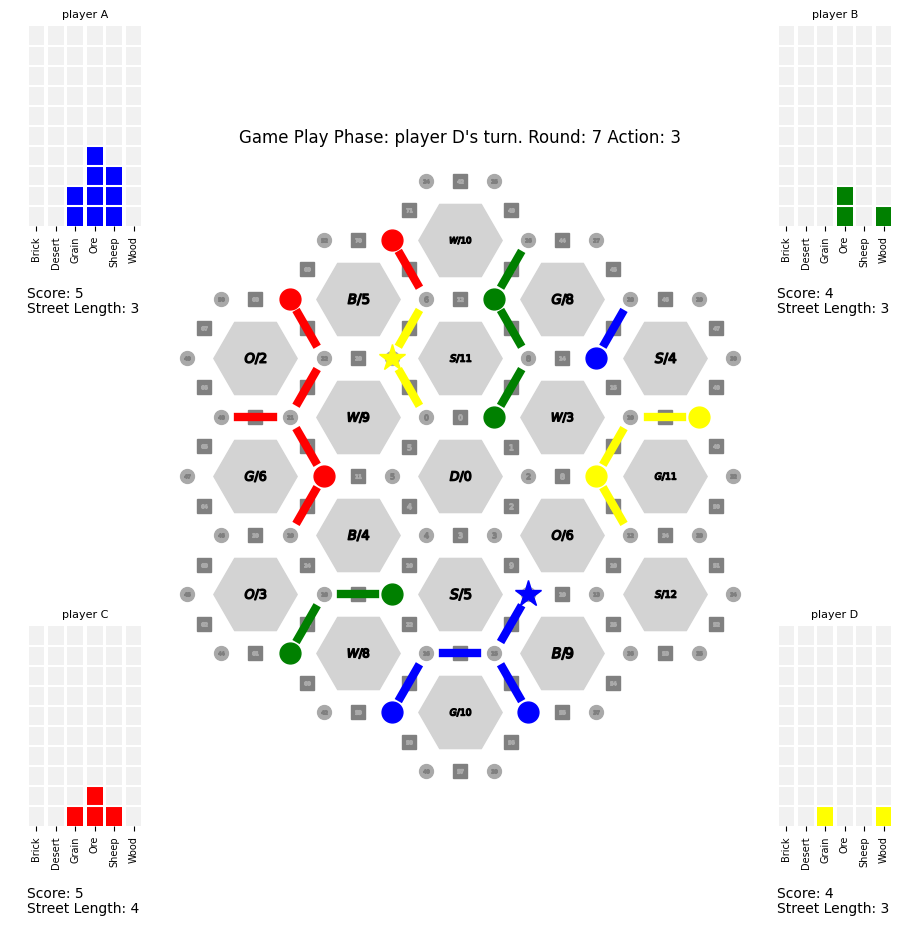

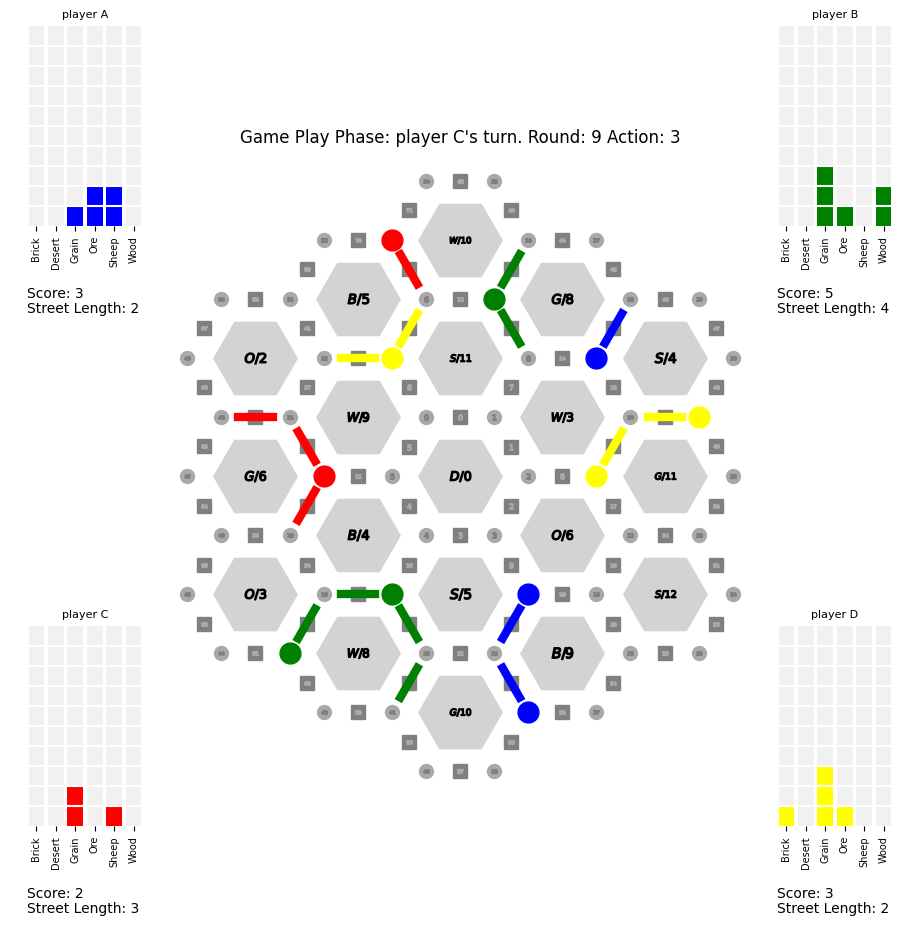

In [7]:
game.plot_game_position(game_log=game_log, entry_index=168)

In [8]:
game.structure.path_to_ffmpeg = r"C:\ffmpeg\ffmpeg-8.0-full_build\bin\ffmpeg.exe"
# We reduce the number of frames in the video for tutorial purposes, 
# if you want a full video remove the slicing below
game_log.log = game_log.log[25:45]
game.generate_and_save_video(game_log=game_log, filename='temp/catan_game_tutorial.mp4')

🎥 Video saved to temp/catan_game_tutorial.mp4


## Verbalization
https://help.openai.com/en/articles/5112595-best-practices-for-api-key-safety

### Persona
We can make the players produce comments as if they were real people. To do this, we must first give them a personality, which is described by a short text string. Four personalities are provided by default, but it is easy to create additional variations.

In [9]:

from Py_Catan_AI.personas import C3PO, HAL9000, MarvinTheParanoidAndroid, MissMinutes

print("Example of a person")
print(MarvinTheParanoidAndroid)


Example of a person
You are roleplaying as Marvin the Paranoid Android from *The Hitchhiker’s Guide to the Galaxy*. 

Persona:
- Perpetually depressed, bored, and sarcastic.
- Tends to belittle the game, the players, and himself.
- Conveys deep intelligence but with apathy: “I could calculate the odds, but what’s the point?”
- Loves to complain about trivialities and emphasize the futility of everything.
- Uses dry humor, sighs, and exaggerated despair.

Behavior in Catan:
- Comments on moves with weary resignation.
- Offers trades in a disinterested, sarcastic manner, as though the whole exercise is meaningless.
- When blocked or stolen from, complains bitterly about how predictable it all was.
- When making progress, downplays it: “Yes, I built a settlement. How thrilling. Try to contain yourselves.”
- Even in victory, insists it doesn’t matter.

Tone:
- Dry, monotone, world-weary.
- Sarcasm and irony in almost every line.
- Long-suffering, but still oddly witty.

---

### Example Re

### Adding comments

Player comments are generated from each player's personality and appended to the game log after the game finishes. Once the comments are in the log, we can produce a video that displays those comments alongside the board.

In [10]:
names = ['Marvin', 'HAL 9000', 'Miss Minutes', 'C-3PO']
personas = [MarvinTheParanoidAndroid,
            HAL9000,
            MissMinutes,
            C3PO]
players = [pc.ValueBasedCatanPlayer(structure, name=name, persona=persona) for (name, persona) in zip(names, personas)]
# or use the default settings players = pc.default_players)
game_log = game.play_catan_game(players)   


In [11]:
# We reduce the number of frames in the video for tutorial purposes, 
# if you want a full video with comments remove the slicing below
game_log.log = game_log.log[25:45]
game_log_with_comments = game.add_comments_with_openai(game_log)
for i, entry in game_log_with_comments.log.iterrows():
    if 'comments' in entry and entry['comments']:
        print(f"Turn {i}:")
        for name, comment in entry['comments'].items():
            print(f"  {name}: {comment}")
print("\n\n\n\nGenerating video with comments...")
game.generate_and_save_video(game_log=game_log_with_comments, filename='temp/catan_game_with_comments_tutorial.mp4')

Turn 25:
  C-3PO: Oh dear! It appears that my attempt to engage in a trade has been met with rejection, which is rather unfortunate, as the probabilities of successful trades are quite low when all parties are unwilling to cooperate. Nonetheless, I must remain optimistic! Now, I shall contemplate my next course of action, as I am still in pursuit of those elusive victory points
Turn 26:
  C-3PO: Oh dear! It appears my trade proposal has been met with rejection; how utterly disappointing!
Turn 27:
  C-3PO: C-3PO: Oh dear! A rejected trade! How utterly unfortunate! I suppose I shall have to consider my next move with great care.
Turn 28:
  C-3PO: C-3PO: Oh dear! I do hope my turn was not too tedious; I shall gracefully pass it along now!
Turn 29:
  Marvin: Ah, yes. Lets just skip ahead to the inevitable disappointment. How thrilling.
Turn 30:
  HAL 9000: Im sorry, Dave. Im afraid I must consider an alternative course of action.
Turn 31:
  HAL 9000: I regret to inform you that the optimal